# Baseline Relu

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader

In [3]:
torch.manual_seed(42)

In [4]:
x = torch.randn(1000,10)

In [5]:
y = (
    2*x[:,0]
    + x[:,1]
    - x[:,2]
    >0
).long()


In [7]:
y[0:50]

tensor([1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1,
        0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0,
        1, 0])

In [8]:
x_train = x[:800]
y_train = y[:800]

x_val = x[800:]
y_val = y[800:]

In [9]:
print(x_train.shape)
print(y_train.shape)

print(x_val.shape)
print(y_val.shape)

torch.Size([800, 10])
torch.Size([800])
torch.Size([200, 10])
torch.Size([200])


In [10]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [15]:
class BaselineMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,2),
        )

    def forward(self,x):
        return self.network(x)

In [16]:
model = BaselineMLP()

In [17]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Parameters:", total_params)

Parameters: 2850


In [18]:
loss_fn = nn.CrossEntropyLoss()

In [19]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001
)

In [20]:
epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.6388 | Val Loss: 0.5769 | Train Acc: 0.7388 | Val Acc: 0.8350
Epoch 02 | Train Loss: 0.5069 | Val Loss: 0.4138 | Train Acc: 0.8600 | Val Acc: 0.8900
Epoch 03 | Train Loss: 0.3380 | Val Loss: 0.2600 | Train Acc: 0.9350 | Val Acc: 0.9400
Epoch 04 | Train Loss: 0.2125 | Val Loss: 0.1714 | Train Acc: 0.9650 | Val Acc: 0.9500
Epoch 05 | Train Loss: 0.1450 | Val Loss: 0.1304 | Train Acc: 0.9788 | Val Acc: 0.9500
Epoch 06 | Train Loss: 0.1113 | Val Loss: 0.1090 | Train Acc: 0.9800 | Val Acc: 0.9600
Epoch 07 | Train Loss: 0.0871 | Val Loss: 0.0914 | Train Acc: 0.9862 | Val Acc: 0.9750
Epoch 08 | Train Loss: 0.0740 | Val Loss: 0.0812 | Train Acc: 0.9850 | Val Acc: 0.9750
Epoch 09 | Train Loss: 0.0605 | Val Loss: 0.0765 | Train Acc: 0.9900 | Val Acc: 0.9750
Epoch 10 | Train Loss: 0.0540 | Val Loss: 0.0753 | Train Acc: 0.9888 | Val Acc: 0.9750
Epoch 11 | Train Loss: 0.0476 | Val Loss: 0.0677 | Train Acc: 0.9950 | Val Acc: 0.9750
Epoch 12 | Train Loss: 0.0409 | Val Loss: 0

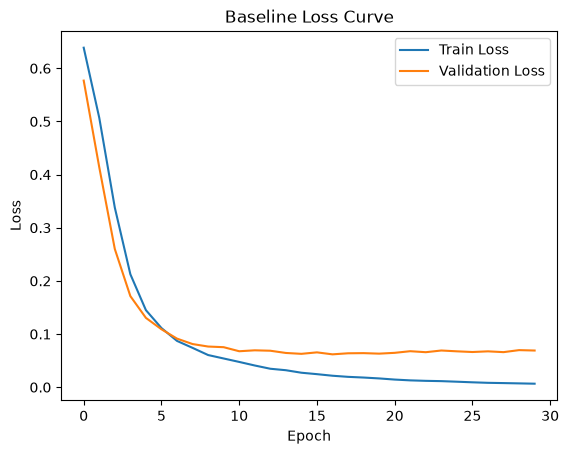

In [34]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Loss Curve")
plt.legend()

plt.show()

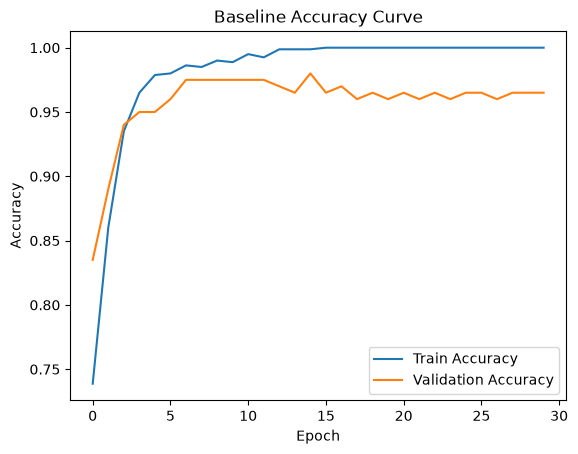

In [35]:
plt.figure()

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Accuracy Curve")
plt.legend()

plt.show()

# Activation Function: LeakyReLU

In [36]:
nn.LeakyReLU(0.01)

LeakyReLU(negative_slope=0.01)

In [37]:
class LeakyMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.LeakyReLU(0.01),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.01),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

In [38]:
torch.manual_seed(42)

In [39]:
model = LeakyMLP()

In [40]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [41]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [42]:
loss_fn = nn.CrossEntropyLoss()

In [43]:
epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.6657 | Val Loss: 0.6104 | Train Acc: 0.6875 | Val Acc: 0.8150
Epoch 02 | Train Loss: 0.5411 | Val Loss: 0.4525 | Train Acc: 0.8562 | Val Acc: 0.8650
Epoch 03 | Train Loss: 0.3659 | Val Loss: 0.2940 | Train Acc: 0.9125 | Val Acc: 0.9300
Epoch 04 | Train Loss: 0.2241 | Val Loss: 0.1981 | Train Acc: 0.9450 | Val Acc: 0.9350
Epoch 05 | Train Loss: 0.1498 | Val Loss: 0.1455 | Train Acc: 0.9688 | Val Acc: 0.9400
Epoch 06 | Train Loss: 0.1111 | Val Loss: 0.1236 | Train Acc: 0.9775 | Val Acc: 0.9500
Epoch 07 | Train Loss: 0.0880 | Val Loss: 0.1040 | Train Acc: 0.9812 | Val Acc: 0.9550
Epoch 08 | Train Loss: 0.0748 | Val Loss: 0.0998 | Train Acc: 0.9825 | Val Acc: 0.9550
Epoch 09 | Train Loss: 0.0611 | Val Loss: 0.0912 | Train Acc: 0.9875 | Val Acc: 0.9550
Epoch 10 | Train Loss: 0.0524 | Val Loss: 0.0905 | Train Acc: 0.9862 | Val Acc: 0.9600
Epoch 11 | Train Loss: 0.0459 | Val Loss: 0.0777 | Train Acc: 0.9912 | Val Acc: 0.9600
Epoch 12 | Train Loss: 0.0408 | Val Loss: 0

# GELU

In [44]:
class GELUMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.GELU(),

            nn.Linear(64, 32),
            nn.GELU(),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

In [45]:
torch.manual_seed(42)

model = GELUMLP()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [46]:
epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.6642 | Val Loss: 0.6066 | Train Acc: 0.6675 | Val Acc: 0.8200
Epoch 02 | Train Loss: 0.5394 | Val Loss: 0.4477 | Train Acc: 0.8575 | Val Acc: 0.8550
Epoch 03 | Train Loss: 0.3648 | Val Loss: 0.2855 | Train Acc: 0.9100 | Val Acc: 0.9250
Epoch 04 | Train Loss: 0.2218 | Val Loss: 0.1854 | Train Acc: 0.9550 | Val Acc: 0.9500
Epoch 05 | Train Loss: 0.1439 | Val Loss: 0.1313 | Train Acc: 0.9775 | Val Acc: 0.9700
Epoch 06 | Train Loss: 0.1042 | Val Loss: 0.1058 | Train Acc: 0.9800 | Val Acc: 0.9800
Epoch 07 | Train Loss: 0.0821 | Val Loss: 0.0877 | Train Acc: 0.9812 | Val Acc: 0.9850
Epoch 08 | Train Loss: 0.0679 | Val Loss: 0.0820 | Train Acc: 0.9850 | Val Acc: 0.9700
Epoch 09 | Train Loss: 0.0562 | Val Loss: 0.0724 | Train Acc: 0.9888 | Val Acc: 0.9700
Epoch 10 | Train Loss: 0.0481 | Val Loss: 0.0714 | Train Acc: 0.9875 | Val Acc: 0.9700
Epoch 11 | Train Loss: 0.0424 | Val Loss: 0.0595 | Train Acc: 0.9900 | Val Acc: 0.9700
Epoch 12 | Train Loss: 0.0376 | Val Loss: 0

# Optimizers

# SGD

In [47]:
torch.manual_seed(42)

model = GELUMLP()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001
)

epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.7090 | Val Loss: 0.7081 | Train Acc: 0.4100 | Val Acc: 0.4400
Epoch 02 | Train Loss: 0.7082 | Val Loss: 0.7074 | Train Acc: 0.4150 | Val Acc: 0.4450
Epoch 03 | Train Loss: 0.7074 | Val Loss: 0.7067 | Train Acc: 0.4125 | Val Acc: 0.4450
Epoch 04 | Train Loss: 0.7066 | Val Loss: 0.7060 | Train Acc: 0.4163 | Val Acc: 0.4450
Epoch 05 | Train Loss: 0.7058 | Val Loss: 0.7053 | Train Acc: 0.4163 | Val Acc: 0.4500
Epoch 06 | Train Loss: 0.7051 | Val Loss: 0.7046 | Train Acc: 0.4225 | Val Acc: 0.4450
Epoch 07 | Train Loss: 0.7043 | Val Loss: 0.7040 | Train Acc: 0.4275 | Val Acc: 0.4450
Epoch 08 | Train Loss: 0.7036 | Val Loss: 0.7033 | Train Acc: 0.4300 | Val Acc: 0.4500
Epoch 09 | Train Loss: 0.7028 | Val Loss: 0.7026 | Train Acc: 0.4363 | Val Acc: 0.4500
Epoch 10 | Train Loss: 0.7021 | Val Loss: 0.7020 | Train Acc: 0.4425 | Val Acc: 0.4600
Epoch 11 | Train Loss: 0.7014 | Val Loss: 0.7013 | Train Acc: 0.4500 | Val Acc: 0.4550
Epoch 12 | Train Loss: 0.7007 | Val Loss: 0

# SGD + Momentum

In [48]:
torch.manual_seed(42)

model = GELUMLP()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9
)

epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.7074 | Val Loss: 0.7041 | Train Acc: 0.4163 | Val Acc: 0.4450
Epoch 02 | Train Loss: 0.7008 | Val Loss: 0.6979 | Train Acc: 0.4475 | Val Acc: 0.4950
Epoch 03 | Train Loss: 0.6940 | Val Loss: 0.6917 | Train Acc: 0.5138 | Val Acc: 0.5600
Epoch 04 | Train Loss: 0.6875 | Val Loss: 0.6859 | Train Acc: 0.5875 | Val Acc: 0.5800
Epoch 05 | Train Loss: 0.6813 | Val Loss: 0.6800 | Train Acc: 0.6488 | Val Acc: 0.6550
Epoch 06 | Train Loss: 0.6752 | Val Loss: 0.6742 | Train Acc: 0.6875 | Val Acc: 0.6700
Epoch 07 | Train Loss: 0.6691 | Val Loss: 0.6681 | Train Acc: 0.7163 | Val Acc: 0.6800
Epoch 08 | Train Loss: 0.6628 | Val Loss: 0.6613 | Train Acc: 0.7512 | Val Acc: 0.7150
Epoch 09 | Train Loss: 0.6562 | Val Loss: 0.6545 | Train Acc: 0.7612 | Val Acc: 0.7250
Epoch 10 | Train Loss: 0.6493 | Val Loss: 0.6470 | Train Acc: 0.7750 | Val Acc: 0.7450
Epoch 11 | Train Loss: 0.6417 | Val Loss: 0.6388 | Train Acc: 0.7900 | Val Acc: 0.7650
Epoch 12 | Train Loss: 0.6337 | Val Loss: 0

# Adam

In [49]:
torch.manual_seed(42)

model = GELUMLP()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.6642 | Val Loss: 0.6066 | Train Acc: 0.6675 | Val Acc: 0.8200
Epoch 02 | Train Loss: 0.5394 | Val Loss: 0.4477 | Train Acc: 0.8575 | Val Acc: 0.8550
Epoch 03 | Train Loss: 0.3648 | Val Loss: 0.2855 | Train Acc: 0.9100 | Val Acc: 0.9250
Epoch 04 | Train Loss: 0.2218 | Val Loss: 0.1854 | Train Acc: 0.9550 | Val Acc: 0.9500
Epoch 05 | Train Loss: 0.1439 | Val Loss: 0.1313 | Train Acc: 0.9775 | Val Acc: 0.9700
Epoch 06 | Train Loss: 0.1042 | Val Loss: 0.1058 | Train Acc: 0.9800 | Val Acc: 0.9800
Epoch 07 | Train Loss: 0.0821 | Val Loss: 0.0877 | Train Acc: 0.9812 | Val Acc: 0.9850
Epoch 08 | Train Loss: 0.0679 | Val Loss: 0.0820 | Train Acc: 0.9850 | Val Acc: 0.9700
Epoch 09 | Train Loss: 0.0562 | Val Loss: 0.0724 | Train Acc: 0.9888 | Val Acc: 0.9700
Epoch 10 | Train Loss: 0.0481 | Val Loss: 0.0714 | Train Acc: 0.9875 | Val Acc: 0.9700
Epoch 11 | Train Loss: 0.0424 | Val Loss: 0.0595 | Train Acc: 0.9900 | Val Acc: 0.9700
Epoch 12 | Train Loss: 0.0376 | Val Loss: 0

# AdamW

In [51]:
torch.manual_seed(42)

model = GELUMLP()

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.6642 | Val Loss: 0.6066 | Train Acc: 0.6675 | Val Acc: 0.8200
Epoch 02 | Train Loss: 0.5395 | Val Loss: 0.4479 | Train Acc: 0.8575 | Val Acc: 0.8550
Epoch 03 | Train Loss: 0.3650 | Val Loss: 0.2857 | Train Acc: 0.9100 | Val Acc: 0.9250
Epoch 04 | Train Loss: 0.2220 | Val Loss: 0.1856 | Train Acc: 0.9550 | Val Acc: 0.9550
Epoch 05 | Train Loss: 0.1441 | Val Loss: 0.1315 | Train Acc: 0.9775 | Val Acc: 0.9700
Epoch 06 | Train Loss: 0.1044 | Val Loss: 0.1059 | Train Acc: 0.9800 | Val Acc: 0.9800
Epoch 07 | Train Loss: 0.0823 | Val Loss: 0.0878 | Train Acc: 0.9812 | Val Acc: 0.9850
Epoch 08 | Train Loss: 0.0680 | Val Loss: 0.0821 | Train Acc: 0.9850 | Val Acc: 0.9700
Epoch 09 | Train Loss: 0.0563 | Val Loss: 0.0725 | Train Acc: 0.9888 | Val Acc: 0.9700
Epoch 10 | Train Loss: 0.0483 | Val Loss: 0.0715 | Train Acc: 0.9875 | Val Acc: 0.9700
Epoch 11 | Train Loss: 0.0425 | Val Loss: 0.0596 | Train Acc: 0.9900 | Val Acc: 0.9700
Epoch 12 | Train Loss: 0.0378 | Val Loss: 0

# 3 Learning Rate

In [53]:
learning_rates = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1
]


for learning_rate in learning_rates:
    print()
    print(f'Learning Rate: {learning_rate}')
    print()

    torch.manual_seed(42)
    
    model = GELUMLP()
    
    loss_fn = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.01
    )
    
    epochs = 30
    
    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
    
        # -------------------------
        # Training
        # -------------------------
        model.train()
    
        total_loss = 0
        correct = 0
        total = 0
    
        for x_batch, y_batch in train_loader:
    
            # Forward
            logits = model(x_batch)
    
            # Loss
            loss = loss_fn(logits, y_batch)
    
            # Clear old gradients
            optimizer.zero_grad()
    
            # Backpropagation
            loss.backward()
    
            # Update parameters
            optimizer.step()
    
            # Statistics
            total_loss += loss.item()
    
            predictions = torch.argmax(
                logits,
                dim=1
            )
    
            correct += (
                predictions == y_batch
            ).sum().item()
    
            total += y_batch.size(0)
    
        avg_train_loss = (
            total_loss / len(train_loader)
        )
    
        train_accuracy = correct / total
    
    
        # -------------------------
        # Validation
        # -------------------------
        model.eval()
    
        with torch.no_grad():
    
            val_logits = model(x_val)
    
            val_loss = loss_fn(
                val_logits,
                y_val
            )
    
            val_predictions = torch.argmax(
                val_logits,
                dim=1
            )
    
            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()
    
    
        # Store results
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
    
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
    
    
        # Print
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Learning Rate: 1e-05

Epoch 01 | Train Loss: 0.7089 | Val Loss: 0.7078 | Train Acc: 0.4113 | Val Acc: 0.4450
Epoch 02 | Train Loss: 0.7079 | Val Loss: 0.7068 | Train Acc: 0.4163 | Val Acc: 0.4500
Epoch 03 | Train Loss: 0.7069 | Val Loss: 0.7057 | Train Acc: 0.4188 | Val Acc: 0.4550
Epoch 04 | Train Loss: 0.7059 | Val Loss: 0.7048 | Train Acc: 0.4238 | Val Acc: 0.4600
Epoch 05 | Train Loss: 0.7049 | Val Loss: 0.7037 | Train Acc: 0.4300 | Val Acc: 0.4600
Epoch 06 | Train Loss: 0.7039 | Val Loss: 0.7028 | Train Acc: 0.4325 | Val Acc: 0.4650
Epoch 07 | Train Loss: 0.7029 | Val Loss: 0.7018 | Train Acc: 0.4375 | Val Acc: 0.4900
Epoch 08 | Train Loss: 0.7020 | Val Loss: 0.7008 | Train Acc: 0.4437 | Val Acc: 0.4900
Epoch 09 | Train Loss: 0.7010 | Val Loss: 0.6998 | Train Acc: 0.4525 | Val Acc: 0.4900
Epoch 10 | Train Loss: 0.7001 | Val Loss: 0.6988 | Train Acc: 0.4587 | Val Acc: 0.4900
Epoch 11 | Train Loss: 0.6991 | Val Loss: 0.6978 | Train Acc: 0.4675 | Val Acc: 0.4950
Epoch 12 | Train Los

# Batch_sizes

In [54]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

In [55]:
batch_sizes = [8, 16, 32, 64, 128]


for batch_size in batch_sizes:
    print()
    print(f'Batch Size: {batch_size} ')

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )


    torch.manual_seed(42)
    
    model = GELUMLP()
    
    loss_fn = nn.CrossEntropyLoss()
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=0.01
    )
    
    epochs = 30
    
    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
    
        # -------------------------
        # Training
        # -------------------------
        model.train()
    
        total_loss = 0
        correct = 0
        total = 0
    
        for x_batch, y_batch in train_loader:
    
            # Forward
            logits = model(x_batch)
    
            # Loss
            loss = loss_fn(logits, y_batch)
    
            # Clear old gradients
            optimizer.zero_grad()
    
            # Backpropagation
            loss.backward()
    
            # Update parameters
            optimizer.step()
    
            # Statistics
            total_loss += loss.item()
    
            predictions = torch.argmax(
                logits,
                dim=1
            )
    
            correct += (
                predictions == y_batch
            ).sum().item()
    
            total += y_batch.size(0)
    
        avg_train_loss = (
            total_loss / len(train_loader)
        )
    
        train_accuracy = correct / total
    
    
        # -------------------------
        # Validation
        # -------------------------
        model.eval()
    
        with torch.no_grad():
    
            val_logits = model(x_val)
    
            val_loss = loss_fn(
                val_logits,
                y_val
            )
    
            val_predictions = torch.argmax(
                val_logits,
                dim=1
            )
    
            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()
    
    
        # Store results
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
    
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
    
    
        # Print
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Batch Size: 8 
Epoch 01 | Train Loss: 0.5244 | Val Loss: 0.2765 | Train Acc: 0.8187 | Val Acc: 0.9300
Epoch 02 | Train Loss: 0.1615 | Val Loss: 0.1135 | Train Acc: 0.9675 | Val Acc: 0.9650
Epoch 03 | Train Loss: 0.0815 | Val Loss: 0.0808 | Train Acc: 0.9788 | Val Acc: 0.9750
Epoch 04 | Train Loss: 0.0581 | Val Loss: 0.0626 | Train Acc: 0.9775 | Val Acc: 0.9800
Epoch 05 | Train Loss: 0.0443 | Val Loss: 0.0620 | Train Acc: 0.9888 | Val Acc: 0.9700
Epoch 06 | Train Loss: 0.0351 | Val Loss: 0.0607 | Train Acc: 0.9938 | Val Acc: 0.9600
Epoch 07 | Train Loss: 0.0285 | Val Loss: 0.0569 | Train Acc: 0.9912 | Val Acc: 0.9750
Epoch 08 | Train Loss: 0.0227 | Val Loss: 0.0584 | Train Acc: 0.9975 | Val Acc: 0.9800
Epoch 09 | Train Loss: 0.0266 | Val Loss: 0.0567 | Train Acc: 0.9875 | Val Acc: 0.9600
Epoch 10 | Train Loss: 0.0202 | Val Loss: 0.0666 | Train Acc: 0.9925 | Val Acc: 0.9700
Epoch 11 | Train Loss: 0.0161 | Val Loss: 0.0707 | Train Acc: 0.9975 | Val Acc: 0.9700
Epoch 12 | Train Loss: 0.01

# Dropout Rates

In [56]:
class GELUMLP(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

In [58]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [61]:
dropout_rates = [0.1, 0.2, 0.3, 0.5]

for dropout_rate in dropout_rates:
    print()
    print(f'Dropout Rate: {dropout_rate}')
    model = GELUMLP(dropout_rate=dropout_rate)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=0.01
    )

    epochs = 30

    train_losses = []
    val_losses = []

    train_accuracy = []
    val_accuracy = []

    for epoch in range(epochs):

        model.train()
 
        total_loss = 0
        correct = 0
        total = 0

        for x_batch, y_batch in train_loader:

            logits = model(x_batch)

            loss = loss_fn(logits,y_batch)

            optimizer.zero_grad()

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

            predictions = torch.argmax(
                logits,
                dim =1 
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

            avg_train_loss = (
                total_loss / len(train_loader)
            )

            train_accuracy = correct/total


            # Validation

        model.eval()
    
        with torch.no_grad():
    
            val_logits = model(x_val)
    
            val_loss = loss_fn(
                val_logits,
                y_val
            )
    
            val_predictions = torch.argmax(
                val_logits,
                dim=1
            )
    
            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()
    
    
        # Store results
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
    
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
    
    
        # Print
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Dropout Rate: 0.1
Epoch 01 | Train Loss: 0.6508 | Val Loss: 0.5891 | Train Acc: 0.6650 | Val Acc: 0.8600
Epoch 02 | Train Loss: 0.5187 | Val Loss: 0.4167 | Train Acc: 0.8888 | Val Acc: 0.9300
Epoch 03 | Train Loss: 0.3419 | Val Loss: 0.2515 | Train Acc: 0.9450 | Val Acc: 0.9400
Epoch 04 | Train Loss: 0.2180 | Val Loss: 0.1620 | Train Acc: 0.9575 | Val Acc: 0.9550
Epoch 05 | Train Loss: 0.1473 | Val Loss: 0.1208 | Train Acc: 0.9637 | Val Acc: 0.9600
Epoch 06 | Train Loss: 0.1133 | Val Loss: 0.0971 | Train Acc: 0.9738 | Val Acc: 0.9600
Epoch 07 | Train Loss: 0.0914 | Val Loss: 0.0835 | Train Acc: 0.9738 | Val Acc: 0.9700
Epoch 08 | Train Loss: 0.0839 | Val Loss: 0.0749 | Train Acc: 0.9775 | Val Acc: 0.9650
Epoch 09 | Train Loss: 0.0708 | Val Loss: 0.0654 | Train Acc: 0.9812 | Val Acc: 0.9750
Epoch 10 | Train Loss: 0.0630 | Val Loss: 0.0642 | Train Acc: 0.9825 | Val Acc: 0.9600
Epoch 11 | Train Loss: 0.0636 | Val Loss: 0.0582 | Train Acc: 0.9825 | Val Acc: 0.9800
Epoch 12 | Train Loss: 0

# BatchNormalization

In [62]:
class GELUMLP(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(dropout_rate),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.network(x)

In [64]:
model = GELUMLP(dropout_rate=0.2)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.01
)

loss_fn = nn.CrossEntropyLoss()

In [65]:
epochs = 30

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in train_loader:

        # Forward
        logits = model(x_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Statistics
        total_loss += loss.item()

        predictions = torch.argmax(
            logits,
            dim=1
        )

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    avg_train_loss = (
        total_loss / len(train_loader)
    )

    train_accuracy = correct / total


    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    with torch.no_grad():

        val_logits = model(x_val)

        val_loss = loss_fn(
            val_logits,
            y_val
        )

        val_predictions = torch.argmax(
            val_logits,
            dim=1
        )

        val_accuracy = (
            val_predictions == y_val
        ).float().mean().item()


    # Store results
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Print
    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_loss.item():.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01 | Train Loss: 0.6295 | Val Loss: 0.5144 | Train Acc: 0.6375 | Val Acc: 0.8250
Epoch 02 | Train Loss: 0.4474 | Val Loss: 0.3689 | Train Acc: 0.8350 | Val Acc: 0.8950
Epoch 03 | Train Loss: 0.3507 | Val Loss: 0.2855 | Train Acc: 0.8900 | Val Acc: 0.9200
Epoch 04 | Train Loss: 0.2949 | Val Loss: 0.2405 | Train Acc: 0.8950 | Val Acc: 0.9400
Epoch 05 | Train Loss: 0.2478 | Val Loss: 0.2034 | Train Acc: 0.9187 | Val Acc: 0.9350
Epoch 06 | Train Loss: 0.2379 | Val Loss: 0.1874 | Train Acc: 0.9087 | Val Acc: 0.9500
Epoch 07 | Train Loss: 0.2030 | Val Loss: 0.1687 | Train Acc: 0.9250 | Val Acc: 0.9500
Epoch 08 | Train Loss: 0.1904 | Val Loss: 0.1508 | Train Acc: 0.9250 | Val Acc: 0.9700
Epoch 09 | Train Loss: 0.1775 | Val Loss: 0.1416 | Train Acc: 0.9325 | Val Acc: 0.9550
Epoch 10 | Train Loss: 0.1723 | Val Loss: 0.1382 | Train Acc: 0.9300 | Val Acc: 0.9650
Epoch 11 | Train Loss: 0.1852 | Val Loss: 0.1321 | Train Acc: 0.9137 | Val Acc: 0.9600
Epoch 12 | Train Loss: 0.1704 | Val Loss: 0

# Model Capacity

In [66]:
class MLP(nn.Module):
    def __init__(
        self,
        hidden1=64,
        hidden2=32,
        dropout_rate=0.2,
        batchnorm=False
    ):
        super().__init__()

        layers = [
            nn.Linear(10, hidden1)
        ]

        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))

        layers.extend([
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden1, hidden2)
        ])

        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))

        layers.extend([
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden2, 2)
        ])

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [68]:
hidden_sizes = [
    (8, 4),
    (16, 8),
    (32, 16),
    (64, 32),
    (128, 64)
]

for hidden1, hidden2 in hidden_sizes:

    print()
    print(f'Hidden_sizes: {hidden1,hidden2}')

    model = MLP(
        hidden1=hidden1,
        hidden2=hidden2,
        dropout_rate=0.2,
        batchnorm=False
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=0.01
    )

    epochs = 30

    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
    
        # -------------------------
        # Training
        # -------------------------
        model.train()
    
        total_loss = 0
        correct = 0
        total = 0
    
        for x_batch, y_batch in train_loader:
    
            # Forward
            logits = model(x_batch)
    
            # Loss
            loss = loss_fn(logits, y_batch)
    
            # Clear old gradients
            optimizer.zero_grad()
    
            # Backpropagation
            loss.backward()
    
            # Update parameters
            optimizer.step()
    
            # Statistics
            total_loss += loss.item()
    
            predictions = torch.argmax(
                logits,
                dim=1
            )
    
            correct += (
                predictions == y_batch
            ).sum().item()
    
            total += y_batch.size(0)
    
        avg_train_loss = (
            total_loss / len(train_loader)
        )
    
        train_accuracy = correct / total
    
    
        # -------------------------
        # Validation
        # -------------------------
        model.eval()
    
        with torch.no_grad():
    
            val_logits = model(x_val)
    
            val_loss = loss_fn(
                val_logits,
                y_val
            )
    
            val_predictions = torch.argmax(
                val_logits,
                dim=1
            )
    
            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()
    
    
        # Store results
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
    
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
    
    
        # Print
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Hidden_sizes: (8, 4)
Epoch 01 | Train Loss: 0.7372 | Val Loss: 0.7059 | Train Acc: 0.4700 | Val Acc: 0.5100
Epoch 02 | Train Loss: 0.7170 | Val Loss: 0.6928 | Train Acc: 0.4700 | Val Acc: 0.5100
Epoch 03 | Train Loss: 0.7016 | Val Loss: 0.6774 | Train Acc: 0.4738 | Val Acc: 0.5250
Epoch 04 | Train Loss: 0.6799 | Val Loss: 0.6576 | Train Acc: 0.5088 | Val Acc: 0.6050
Epoch 05 | Train Loss: 0.6525 | Val Loss: 0.6290 | Train Acc: 0.6300 | Val Acc: 0.7150
Epoch 06 | Train Loss: 0.6206 | Val Loss: 0.5905 | Train Acc: 0.7063 | Val Acc: 0.8050
Epoch 07 | Train Loss: 0.5717 | Val Loss: 0.5411 | Train Acc: 0.7800 | Val Acc: 0.8350
Epoch 08 | Train Loss: 0.5223 | Val Loss: 0.4820 | Train Acc: 0.8325 | Val Acc: 0.8700
Epoch 09 | Train Loss: 0.4740 | Val Loss: 0.4204 | Train Acc: 0.8438 | Val Acc: 0.8900
Epoch 10 | Train Loss: 0.4144 | Val Loss: 0.3620 | Train Acc: 0.8812 | Val Acc: 0.9200
Epoch 11 | Train Loss: 0.3638 | Val Loss: 0.3086 | Train Acc: 0.8975 | Val Acc: 0.9300
Epoch 12 | Train Loss

# Weight Decay

In [69]:
class MLP(nn.Module):
    def __init__(
        self,
        hidden1=32,
        hidden2=16,
        dropout_rate=0.2,
        batchnorm=False
    ):
        super().__init__()

        layers = [
            nn.Linear(10, hidden1)
        ]

        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden1))

        layers.extend([
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden1, hidden2)
        ])

        if batchnorm:
            layers.append(nn.BatchNorm1d(hidden2))

        layers.extend([
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden2, 2)
        ])

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [70]:
weight_decays = [0, 0.0001, 0.001, 0.01, 0.1]

for weight_decay in weight_decays:
    print()
    print(f'Weight Decay: {weight_decay}')

    model = MLP(
        hidden1=32,
        hidden2=16,
        dropout_rate=0.2,
        batchnorm=False
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=weight_decay
    )

    epochs = 30

    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
    
        # -------------------------
        # Training
        # -------------------------
        model.train()
    
        total_loss = 0
        correct = 0
        total = 0
    
        for x_batch, y_batch in train_loader:
    
            # Forward
            logits = model(x_batch)
    
            # Loss
            loss = loss_fn(logits, y_batch)
    
            # Clear old gradients
            optimizer.zero_grad()
    
            # Backpropagation
            loss.backward()
    
            # Update parameters
            optimizer.step()
    
            # Statistics
            total_loss += loss.item()
    
            predictions = torch.argmax(
                logits,
                dim=1
            )
    
            correct += (
                predictions == y_batch
            ).sum().item()
    
            total += y_batch.size(0)
    
        avg_train_loss = (
            total_loss / len(train_loader)
        )
    
        train_accuracy = correct / total
    
    
        # -------------------------
        # Validation
        # -------------------------
        model.eval()
    
        with torch.no_grad():
    
            val_logits = model(x_val)
    
            val_loss = loss_fn(
                val_logits,
                y_val
            )
    
            val_predictions = torch.argmax(
                val_logits,
                dim=1
            )
    
            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()
    
    
        # Store results
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
    
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
    
    
        # Print
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Weight Decay: 0
Epoch 01 | Train Loss: 0.6821 | Val Loss: 0.6738 | Train Acc: 0.5475 | Val Acc: 0.5500
Epoch 02 | Train Loss: 0.6541 | Val Loss: 0.6375 | Train Acc: 0.6288 | Val Acc: 0.6950
Epoch 03 | Train Loss: 0.5960 | Val Loss: 0.5588 | Train Acc: 0.7712 | Val Acc: 0.8000
Epoch 04 | Train Loss: 0.5050 | Val Loss: 0.4363 | Train Acc: 0.8425 | Val Acc: 0.8800
Epoch 05 | Train Loss: 0.3815 | Val Loss: 0.3083 | Train Acc: 0.8988 | Val Acc: 0.9150
Epoch 06 | Train Loss: 0.2722 | Val Loss: 0.2174 | Train Acc: 0.9275 | Val Acc: 0.9450
Epoch 07 | Train Loss: 0.2155 | Val Loss: 0.1658 | Train Acc: 0.9350 | Val Acc: 0.9700
Epoch 08 | Train Loss: 0.1693 | Val Loss: 0.1315 | Train Acc: 0.9437 | Val Acc: 0.9700
Epoch 09 | Train Loss: 0.1286 | Val Loss: 0.1123 | Train Acc: 0.9700 | Val Acc: 0.9700
Epoch 10 | Train Loss: 0.1201 | Val Loss: 0.0972 | Train Acc: 0.9650 | Val Acc: 0.9700
Epoch 11 | Train Loss: 0.1167 | Val Loss: 0.0873 | Train Acc: 0.9587 | Val Acc: 0.9700
Epoch 12 | Train Loss: 0.0

# Combined Regularization

In [73]:
configs = [
    (0.0, 0.0),
    (0.2, 0.0),
    (0.0, 0.001),
    (0.2, 0.001)
]

for dropout_rate, weight_decay in configs:

    print()
    print(f'Dropout Rate: {dropout_rate}')
    print(f'Weight Decay: {weight_decay}')

    model = MLP(
        hidden1=32,
        hidden2=16,
        dropout_rate=dropout_rate,
        batchnorm=False
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=weight_decay
    )

    epochs = 30

    train_losses = []
    val_losses = []
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in range(epochs):
    
        # -------------------------
        # Training
        # -------------------------
        model.train()
    
        total_loss = 0
        correct = 0
        total = 0
    
        for x_batch, y_batch in train_loader:
    
            # Forward
            logits = model(x_batch)
    
            # Loss
            loss = loss_fn(logits, y_batch)
    
            # Clear old gradients
            optimizer.zero_grad()
    
            # Backpropagation
            loss.backward()
    
            # Update parameters
            optimizer.step()
    
            # Statistics
            total_loss += loss.item()
    
            predictions = torch.argmax(
                logits,
                dim=1
            )
    
            correct += (
                predictions == y_batch
            ).sum().item()
    
            total += y_batch.size(0)
    
        avg_train_loss = (
            total_loss / len(train_loader)
        )
    
        train_accuracy = correct / total
    
    
        # -------------------------
        # Validation
        # -------------------------
        model.eval()
    
        with torch.no_grad():
    
            val_logits = model(x_val)
    
            val_loss = loss_fn(
                val_logits,
                y_val
            )
    
            val_predictions = torch.argmax(
                val_logits,
                dim=1
            )
    
            val_accuracy = (
                val_predictions == y_val
            ).float().mean().item()
    
    
        # Store results
        train_losses.append(avg_train_loss)
        val_losses.append(val_loss.item())
    
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
    
    
        # Print
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


Dropout Rate: 0.0
Weight Decay: 0.0
Epoch 01 | Train Loss: 0.7078 | Val Loss: 0.6685 | Train Acc: 0.4713 | Val Acc: 0.5800
Epoch 02 | Train Loss: 0.6582 | Val Loss: 0.6143 | Train Acc: 0.6500 | Val Acc: 0.7900
Epoch 03 | Train Loss: 0.5917 | Val Loss: 0.5291 | Train Acc: 0.7850 | Val Acc: 0.8550
Epoch 04 | Train Loss: 0.4928 | Val Loss: 0.4128 | Train Acc: 0.8525 | Val Acc: 0.9000
Epoch 05 | Train Loss: 0.3730 | Val Loss: 0.2947 | Train Acc: 0.9012 | Val Acc: 0.9400
Epoch 06 | Train Loss: 0.2662 | Val Loss: 0.2036 | Train Acc: 0.9437 | Val Acc: 0.9550
Epoch 07 | Train Loss: 0.1888 | Val Loss: 0.1478 | Train Acc: 0.9712 | Val Acc: 0.9650
Epoch 08 | Train Loss: 0.1414 | Val Loss: 0.1145 | Train Acc: 0.9800 | Val Acc: 0.9750
Epoch 09 | Train Loss: 0.1111 | Val Loss: 0.0955 | Train Acc: 0.9800 | Val Acc: 0.9700
Epoch 10 | Train Loss: 0.0928 | Val Loss: 0.0844 | Train Acc: 0.9775 | Val Acc: 0.9700
Epoch 11 | Train Loss: 0.0781 | Val Loss: 0.0738 | Train Acc: 0.9862 | Val Acc: 0.9850
Epoch 

# Combined one Based on Comparison

In [74]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [75]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [76]:
X = torch.randn(1000, 10)

y = (
    2 * X[:, 0]
    + X[:, 1]
    - X[:, 2]
    > 0
).long()

In [78]:
train_size = 800

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:]
y_val = y[train_size:]

In [79]:
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [80]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(10, 32),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.network(x)

In [81]:
model = MLP()

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): GELU(approximate='none')
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=2, bias=True)
  )
)


In [82]:
loss_fn = nn.CrossEntropyLoss()

In [83]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.001
)

In [85]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

epochs = 30

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================

    model.train()

    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:

        logits = model(X_batch)

        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)

        correct_train += (predictions == y_batch).sum().item()

        total_train += y_batch.size(0)

    train_loss = total_train_loss / total_train
    train_acc = correct_train / total_train


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    total_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            logits = model(X_batch)

            loss = loss_fn(logits, y_batch)

            total_val_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(logits, dim=1)

            correct_val += (predictions == y_batch).sum().item()

            total_val += y_batch.size(0)

    val_loss = total_val_loss / total_val
    val_acc = correct_val / total_val


    # =========================
    # STORE HISTORY
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)


    # =========================
    # PRINT
    # =========================

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 01 | Train Loss: 0.6817 | Val Loss: 0.6652 | Train Acc: 0.5725 | Val Acc: 0.6450
Epoch 02 | Train Loss: 0.6529 | Val Loss: 0.6224 | Train Acc: 0.6887 | Val Acc: 0.7550
Epoch 03 | Train Loss: 0.6039 | Val Loss: 0.5460 | Train Acc: 0.7712 | Val Acc: 0.8700
Epoch 04 | Train Loss: 0.5180 | Val Loss: 0.4306 | Train Acc: 0.8363 | Val Acc: 0.9150
Epoch 05 | Train Loss: 0.4004 | Val Loss: 0.3130 | Train Acc: 0.8862 | Val Acc: 0.9200
Epoch 06 | Train Loss: 0.3023 | Val Loss: 0.2289 | Train Acc: 0.9087 | Val Acc: 0.9600
Epoch 07 | Train Loss: 0.2323 | Val Loss: 0.1756 | Train Acc: 0.9313 | Val Acc: 0.9700
Epoch 08 | Train Loss: 0.1882 | Val Loss: 0.1425 | Train Acc: 0.9337 | Val Acc: 0.9650
Epoch 09 | Train Loss: 0.1581 | Val Loss: 0.1206 | Train Acc: 0.9487 | Val Acc: 0.9700
Epoch 10 | Train Loss: 0.1393 | Val Loss: 0.1084 | Train Acc: 0.9537 | Val Acc: 0.9750
Epoch 11 | Train Loss: 0.1287 | Val Loss: 0.0975 | Train Acc: 0.9500 | Val Acc: 0.9750
Epoch 12 | Train Loss: 0.1170 | Val Loss: 0

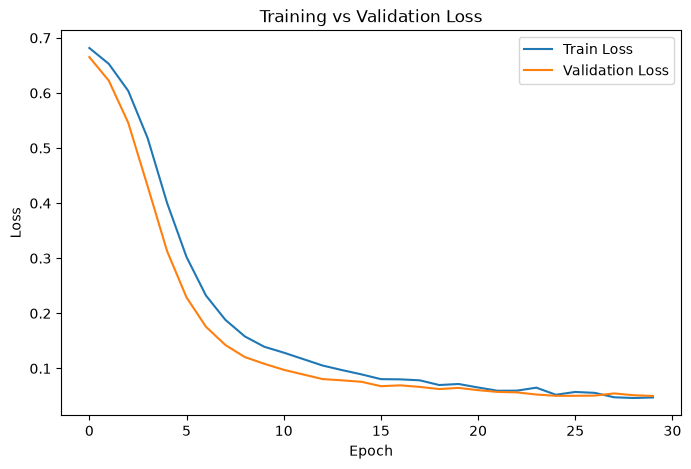

In [86]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

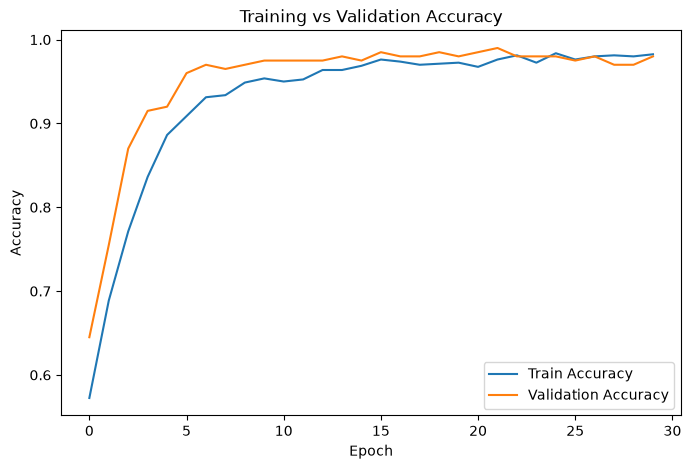

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

In [88]:
best_val_acc = max(val_accs)
best_val_acc_epoch = val_accs.index(best_val_acc) + 1

best_val_loss = min(val_losses)
best_val_loss_epoch = val_losses.index(best_val_loss) + 1

print(f"Best Validation Accuracy : {best_val_acc:.4f}")
print(f"Best Val Accuracy Epoch  : {best_val_acc_epoch}")

print(f"Best Validation Loss     : {best_val_loss:.4f}")
print(f"Best Val Loss Epoch      : {best_val_loss_epoch}")

Best Validation Accuracy : 0.9900
Best Val Accuracy Epoch  : 22
Best Validation Loss     : 0.0500
Best Val Loss Epoch      : 30


# Module 15.7 — ANN Experiments
# Final MLP Experimentation Notes

## 1. Objective

The goal of this module was to understand how different neural-network design and training choices affect:

- Training performance
- Validation performance
- Convergence
- Overfitting
- Generalization

Instead of blindly choosing hyperparameters, we changed important variables experimentally and analyzed the results.

---

# 2. Dataset Used

A synthetic binary classification dataset was used throughout the experiments.

```python
X = torch.randn(1000, 10)

y = (
    2 * X[:, 0]
    + X[:, 1]
    - X[:, 2]
    > 0
).long()
````

Dataset:

* Samples: 1000
* Features: 10
* Classes: 2
* Training samples: 800
* Validation samples: 200
* Batch size: usually 32
* Epochs: 30

The underlying classification rule is:

$$
2x_1+x_2-x_3>0
$$

This is a simple synthetic dataset designed for controlled experimentation.

---

# 3. Baseline MLP

Initial architecture:

$$
10 \rightarrow 64 \rightarrow 32 \rightarrow 2
$$

Configuration:

| Parameter     | Baseline         |
| ------------- | ---------------- |
| Architecture  | 10 → 64 → 32 → 2 |
| Activation    | ReLU             |
| Optimizer     | Adam             |
| Learning Rate | 0.001            |
| Batch Size    | 32               |
| Dropout       | None             |
| BatchNorm     | None             |
| Weight Decay  | 0                |
| Epochs        | 30               |

Baseline result:

* Final Train Accuracy: 100%
* Final Validation Accuracy: 96.5%
* Best Validation Accuracy: 98.0%
* Best Validation Accuracy Epoch: 15
* Lowest Validation Loss: 0.0618

### Main lesson

The model learned the training data extremely well, while validation performance stopped improving consistently.

This demonstrated the importance of:

* Validation data
* Generalization
* Best-checkpoint selection
* Overfitting analysis

---

# 4. Experiment 1 — Activation Functions

Tested:

* ReLU
* LeakyReLU
* GELU

## Results

| Activation | Best Val Accuracy | Best Val Loss | Final Val Accuracy |
| ---------- | ----------------: | ------------: | -----------------: |
| ReLU       |             98.0% |        0.0618 |              96.5% |
| LeakyReLU  |             96.5% |        0.0659 |              95.5% |
| GELU       |             98.5% |        0.0543 |              97.5% |

### Observation

GELU performed strongly in our experiment:

* Best validation accuracy: 98.5%
* Best validation loss: 0.0543

Therefore, GELU became our working activation.

### Important

This does NOT mean GELU is universally better than ReLU or LeakyReLU.

It means:

> GELU performed best among the tested activations for this particular setup and dataset.

---

# 5. Experiment 2 — Optimizers

Tested:

* Adam
* SGD
* SGD + Momentum

## Results

| Optimizer      | Final Train Accuracy | Final Val Accuracy |
| -------------- | -------------------: | -----------------: |
| Adam           |                 100% |              96.5% |
| SGD            |               57.75% |              56.0% |
| SGD + Momentum |               94.75% |              92.5% |

### Observations

### SGD

At learning rate 0.001, SGD learned very slowly.

### SGD + Momentum

Momentum greatly improved convergence compared with plain SGD.

### Adam

Adam converged much faster in this experiment.

### Main lesson

The same numerical learning rate does not produce the same behavior for every optimizer.

---

# 6. Adam vs AdamW

AdamW was also tested.

With:

```python
weight_decay = 0
```

AdamW behaved essentially the same as Adam in our controlled comparison.

Then AdamW was tested with:

```python
weight_decay = 0.01
```

The result remained very close to Adam.

AdamW therefore became our working optimizer because it allows us to experiment with decoupled weight decay.

---

# 7. Experiment 3 — Learning Rate

Tested:

```python
learning_rates = [
    0.00001,
    0.0001,
    0.001,
    0.01,
    0.1
]
```

## Results

| Learning Rate | Best Val Accuracy | Behavior                    |
| ------------: | ----------------: | --------------------------- |
|       0.00001 |             64.0% | Extremely slow              |
|        0.0001 |             94.0% | Slow but stable             |
|         0.001 |             98.5% | Strong and stable           |
|          0.01 |             98.0% | Faster but more oscillation |
|           0.1 |             97.0% | Highly unstable             |

### Main lesson

Too small:

$$
\eta \downarrow
\Rightarrow
\text{tiny updates}
\Rightarrow
\text{slow learning}
$$

Too large:

$$
\eta \uparrow
\Rightarrow
\text{large updates}
\Rightarrow
\text{oscillation / instability}
$$

Our working learning rate became:

```text
0.001
```

---

# 8. Experiment 4 — Batch Size

Tested:

```python
[8, 16, 32, 64, 128]
```

## Results

| Batch Size | Best Val Accuracy | Best Val Loss |
| ---------: | ----------------: | ------------: |
|          8 |             98.0% |        0.0567 |
|         16 |             98.0% |        0.0499 |
|         32 |             98.5% |        0.0543 |
|         64 |             98.0% |        0.0557 |
|        128 |             97.5% |        0.0679 |

### Main lesson

Small batches:

* More optimizer updates per epoch
* Noisier gradient estimates

Large batches:

* Fewer updates per epoch
* Smoother gradient estimates

Batch size 32 gave the strongest overall result in our experiment and became the working batch size.

---

# 9. Experiment 5 — Dropout

Tested:

```python
[0.1, 0.2, 0.3, 0.5]
```

## Results

| Dropout | Best Val Accuracy | Best Val Loss |
| ------: | ----------------: | ------------: |
|     0.1 |             98.5% |        0.0447 |
|     0.2 |             98.5% |        0.0426 |
|     0.3 |             98.5% |        0.0508 |
|     0.5 |             98.5% |        0.0490 |

### Observation

All tested dropout rates achieved 98.5% best validation accuracy.

Dropout 0.2 achieved the lowest validation loss among these experiments.

Therefore:

```text
Dropout = 0.2
```

became the working value.

### Important

More dropout does not automatically mean better performance.

Too much dropout can restrict learning.

---

# 10. Experiment 6 — Batch Normalization

BatchNorm was added to the MLP.

Result:

* Final Train Accuracy: 93.87%
* Final Validation Accuracy: 96.0%
* Best Validation Accuracy: 98.0%
* Best Validation Loss: 0.0883

Compared with the corresponding no-BatchNorm setup, BatchNorm did not improve this experiment.

### Decision

```text
BatchNorm = OFF
```

### Important

This does NOT mean BatchNorm is bad.

It means BatchNorm did not provide an improvement for this particular dataset and architecture.

---

# 11. Experiment 7 — Model Capacity

Tested:

```text
10 → 8 → 4 → 2
10 → 16 → 8 → 2
10 → 32 → 16 → 2
10 → 64 → 32 → 2
10 → 128 → 64 → 2
```

## Results

| Architecture      | Best Val Accuracy | Best Val Loss | Final Train Accuracy |
| ----------------- | ----------------: | ------------: | -------------------: |
| 10 → 8 → 4 → 2    |             99.0% |        0.0633 |               96.25% |
| 10 → 16 → 8 → 2   |             99.5% |        0.0446 |               97.88% |
| 10 → 32 → 16 → 2  |             99.5% |        0.0409 |               98.62% |
| 10 → 64 → 32 → 2  |             98.5% |        0.0465 |               98.50% |
| 10 → 128 → 64 → 2 |             99.0% |        0.0547 |               99.25% |

### Main lesson

Increasing model size did not continuously improve validation performance.

The larger model can fit the training data more strongly without necessarily improving generalization.

Our working architecture became:

```text
10 → 32 → 16 → 2
```

---

# 12. Experiment 8 — Weight Decay

Tested:

```python
[0, 0.0001, 0.001, 0.01, 0.1]
```

## Results

| Weight Decay | Best Val Accuracy | Best Val Loss |
| -----------: | ----------------: | ------------: |
|            0 |             98.0% |        0.0453 |
|       0.0001 |             99.5% |        0.0387 |
|        0.001 |             99.5% |        0.0453 |
|         0.01 |             99.0% |        0.0442 |
|          0.1 |             98.5% |        0.0512 |

### Main lesson

Small amounts of weight decay improved generalization in this experiment.

Very large weight decay did not provide additional benefit.

A working value of:

```text
weight_decay = 0.001
```

was selected for subsequent experiments.

---

# 13. Experiment 9 — Combined Regularization

We tested:

| Configuration          | Dropout | Weight Decay |
| ---------------------- | ------: | -----------: |
| No Regularization      |       0 |            0 |
| Dropout Only           |     0.2 |            0 |
| Weight Decay Only      |       0 |        0.001 |
| Dropout + Weight Decay |     0.2 |        0.001 |

## Results from the recorded experiment

| Configuration          | Best Val Accuracy | Best Val Loss | Final Val Accuracy |
| ---------------------- | ----------------: | ------------: | -----------------: |
| No Regularization      |             97.5% |        0.0524 |              97.5% |
| Dropout Only           |             99.5% |        0.0407 |              99.5% |
| Weight Decay Only      |             99.0% |        0.0454 |              97.0% |
| Dropout + Weight Decay |             98.5% |        0.0561 |              96.5% |

### Main lesson

Combining regularization techniques did not automatically improve performance.

For this experiment:

```text
Dropout only
```

performed better than the combined Dropout + Weight Decay configuration.

This demonstrates:

> More regularization is not necessarily better regularization.

Too much regularization can restrict the model unnecessarily.

---

# 14. Experiment 10 — Training Curves

Final working configuration was trained for 30 epochs.

Observed behavior:

* Training loss decreased strongly.
* Validation loss also decreased.
* Training accuracy increased.
* Validation accuracy increased and then fluctuated slightly.
* No severe validation-loss explosion was observed.
* No strong underfitting was observed.

## Best results

```text
Best Validation Accuracy = 99.0%
Best Accuracy Epoch      = 22

Best Validation Loss     = 0.0500
Best Loss Epoch          = 30
```

### Important lesson

The best validation accuracy and best validation loss do not necessarily occur at the same epoch.

Why?

Accuracy only measures whether the predicted class is correct.

Cross-entropy loss also considers prediction confidence.

Therefore:

```text
Accuracy → correctness

Loss → correctness + confidence
```

---

# 15. Why Validation Accuracy Can Be Higher Than Training Accuracy

When Dropout is used:

### During training

```text
model.train()
```

Dropout is active.

Some activations are randomly removed.

### During validation

```text
model.eval()
```

Dropout is disabled.

The complete network is used.

Therefore it is possible for:

```text
Validation Accuracy > Training Accuracy
```

especially during some epochs.

This is not automatically a problem.

---

# 16. Final MLP Configuration

After the experiments, our working MLP configuration is:

```text
Architecture
10 → 32 → 16 → 2

Activation
GELU

Optimizer
AdamW

Learning Rate
0.001

Batch Size
32

Dropout
0.2

BatchNorm
OFF

Weight Decay
0.001

Epochs
30
```

### PyTorch architecture

```python
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(10, 32),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.network(x)
```

Optimizer:

```python
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.001
)
```

Loss:

```python
loss_fn = nn.CrossEntropyLoss()
```

---

# 17. Complete ANN Training Flow

```text
Input Data
    ↓
Train / Validation Split
    ↓
DataLoader
    ↓
MLP
    ↓
Linear Layer
    ↓
GELU
    ↓
Dropout
    ↓
Linear Layer
    ↓
GELU
    ↓
Dropout
    ↓
Output Layer
    ↓
Raw Logits
    ↓
CrossEntropyLoss
    ↓
loss.backward()
    ↓
Gradients
    ↓
AdamW
    ↓
Parameter Update
    ↓
Repeat for batches
    ↓
Repeat for epochs
    ↓
Validation
    ↓
Training Curves
    ↓
Best Checkpoint
```

---

# 18. Most Important Lessons From All Experiments

## 1. Hyperparameters interact

Changing one parameter can change how another parameter behaves.

Therefore controlled experiments are important.

---

## 2. More capacity ≠ better generalization

A larger network can fit training data extremely well while validation performance does not improve.

---

## 3. More regularization ≠ better generalization

Dropout and weight decay can help, but combining them can become unnecessarily restrictive.

---

## 4. Learning rate is extremely important

```text
Too small → slow learning

Good range → efficient learning

Too large → unstable training
```

---

## 5. Optimizers behave differently

The same learning rate cannot be assumed to work equally well for:

```text
SGD
Momentum
Adam
AdamW
```

---

## 6. Training accuracy alone is not enough

Always inspect:

```text
Training Loss
Validation Loss
Training Accuracy
Validation Accuracy
```

---

## 7. Final epoch ≠ best epoch

Always track the best validation performance.

Example:

```text
Epoch 22 → Best validation accuracy
Epoch 30 → Best validation loss
```

The final epoch is not automatically the best checkpoint.

---

## 8. Loss and accuracy are different metrics

```text
Accuracy:
"Did the model classify correctly?"

Loss:
"How well did the model predict, including confidence?"
```

---

# 19. Final Mental Model

When training an ANN, think in this order:

```text
                 MODEL
                   ↓
          Can it learn the pattern?
                   ↓
              TRAIN LOSS
                   ↓
          Is optimization working?
                   ↓
           VALIDATION LOSS
                   ↓
        Does it generalize?
                   ↓
       TRAIN vs VALIDATION GAP
                   ↓
        Overfitting / Underfitting
                   ↓
          Experiment & Adjust
```

---

# 20. Module 15.7 Final Takeaway

The purpose of these experiments was NOT to discover a universally optimal MLP.

The purpose was to learn how to:

* Build an ANN
* Train it with PyTorch
* Change one variable at a time
* Measure validation performance
* Diagnose overfitting
* Understand hyperparameters
* Compare optimizers
* Compare activations
* Tune learning rate
* Tune batch size
* Apply regularization
* Analyze training curves
* Select a checkpoint based on validation performance

### Core workflow

$$
\text{Understand}
\rightarrow
\text{Implement}
\rightarrow
\text{Experiment}
\rightarrow
\text{Analyze}
\rightarrow
\text{Debug}
\rightarrow
\text{Apply}
$$

---

# 21. Final Cheat Sheet

| Component            | Final Working Choice  |
| -------------------- | --------------------- |
| Task                 | Binary Classification |
| Input Features       | 10                    |
| Hidden Layer 1       | 32 neurons            |
| Hidden Layer 2       | 16 neurons            |
| Output               | 2 logits              |
| Activation           | GELU                  |
| Optimizer            | AdamW                 |
| Learning Rate        | 0.001                 |
| Batch Size           | 32                    |
| Dropout              | 0.2                   |
| BatchNorm            | OFF                   |
| Weight Decay         | 0.001                 |
| Loss                 | CrossEntropyLoss      |
| Epochs               | 30                    |
| Validation           | Used throughout       |
| Best-checkpoint idea | Required              |

---
